In [3]:
import pandas as pd

df = pd.read_csv(r"D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\salary-dataset (1).csv")

print(df.head())

   Unnamed: 0  YearsExperience  Salary
0           0              1.2   39344
1           1              1.4   46206
2           2              1.6   37732
3           3              2.1   43526
4           4              2.3   39892


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [5]:
#Load Dataset
df = pd.read_csv("salary-dataset (1).csv")

print(df.head())
print(df.info())

   Unnamed: 0  YearsExperience  Salary
0           0              1.2   39344
1           1              1.4   46206
2           2              1.6   37732
3           3              2.1   43526
4           4              2.3   39892
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       36 non-null     int64  
 1   YearsExperience  36 non-null     float64
 2   Salary           36 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 996.0 bytes
None


In [6]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Features and Target
X = df[['YearsExperience']]
y = df['Salary']

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


In [9]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
#Train Model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [11]:
#Evaluate Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)

mse_linear = mean_squared_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mse_linear)

print("Linear Regression Results")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)

Linear Regression Results
MAE : 5802.505173402057
MSE : 39318711.54162893
RMSE: 6270.463423195205


In [12]:
#Create Polynomial Features

# Degree = 2

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [13]:
#Train Polynomial Model
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [14]:
#Evaluate Polynomial Regression
mae_poly = mean_absolute_error(y_test, y_pred_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)

rmse_poly = np.sqrt(mse_poly)

print("\nPolynomial Regression Results")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)


Polynomial Regression Results
MAE : 5435.0146832075925
MSE : 37704204.94100628
RMSE: 6140.374983745397


In [15]:
#Compare Results
results = pd.DataFrame({
    'Model':['Linear Regression','Polynomial Regression'],
    'MAE':[mae_linear, mae_poly],
    'MSE':[mse_linear, mse_poly],
    'RMSE':[rmse_linear, rmse_poly]
})

print(results)

                   Model          MAE           MSE         RMSE
0      Linear Regression  5802.505173  3.931871e+07  6270.463423
1  Polynomial Regression  5435.014683  3.770420e+07  6140.374984


In [16]:
# ── 3. Linear Regression ─────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("\n=== Linear Regression ===")
print(f"  Coefficient : {lr.coef_[0]:.2f}")
print(f"  Intercept   : {lr.intercept_:.2f}")
print(f"  MAE  : {mae_lr:,.2f}")
print(f"  MSE  : {mse_lr:,.2f}")
print(f"  RMSE : {rmse_lr:,.2f}")


=== Linear Regression ===
  Coefficient : 9035.51
  Intercept   : 27350.91
  MAE  : 5,802.51
  MSE  : 39,318,711.54
  RMSE : 6,270.46


In [21]:


# ── 4. Polynomial Regression (degree = 2) ────────────────────────────────────
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
X_test_poly  = scaler.transform(poly.transform(X_test))

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)

mae_pr  = mean_absolute_error(y_test, y_pred_pr)
mse_pr  = mean_squared_error(y_test, y_pred_pr)
rmse_pr = np.sqrt(mse_pr)

print(f"\n=== Polynomial Regression (degree={degree}) ===")
print(f"  MAE  : {mae_pr:,.2f}")
print(f"  MSE  : {mse_pr:,.2f}")
print(f"  RMSE : {rmse_pr:,.2f}")



=== Polynomial Regression (degree=2) ===
  MAE  : 5,435.01
  MSE  : 37,704,204.94
  RMSE : 6,140.37



=== Error Metrics Comparison ===
                        Model         MAE          MSE        RMSE
            Linear Regression 5802.505173 3.931871e+07 6270.463423
Polynomial Regression (deg=2) 5435.014683 3.770420e+07 6140.374984


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


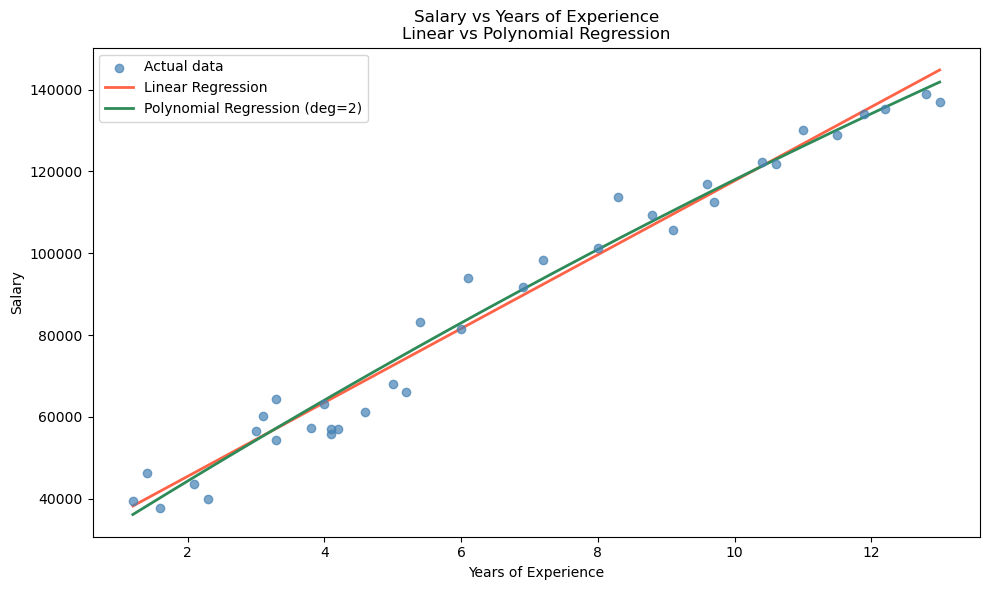


Plot saved to regression_comparison.png


In [26]:
# ── 5. Comparison table ───────────────────────────────────────────────────────
print("\n=== Error Metrics Comparison ===")
metrics = pd.DataFrame({
    "Model": ["Linear Regression", f"Polynomial Regression (deg={degree})"],
    "MAE":   [mae_lr, mae_pr],
    "MSE":   [mse_lr, mse_pr],
    "RMSE":  [rmse_lr, rmse_pr],
})
print(metrics.to_string(index=False))

# ── 6. Plot ───────────────────────────────────────────────────────────────────
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_range_lr = lr.predict(X_range)
y_range_pr = pr.predict(scaler.transform(poly.transform(X_range)))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="steelblue", label="Actual data", alpha=0.7, zorder=3)
plt.plot(X_range, y_range_lr, color="tomato",    linewidth=2, label="Linear Regression")
plt.plot(X_range, y_range_pr, color="seagreen",  linewidth=2, label=f"Polynomial Regression (deg={degree})")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience\nLinear vs Polynomial Regression")
plt.legend()
plt.tight_layout()
plt.savefig(
    r"D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\regression_comparison.png",
    dpi=150
)
plt.show()
print("\nPlot saved to regression_comparison.png")